Notebook to perform OM optimization with the Muller-Brown potential, assuming we have access to the analytical potential and no data/samples from MD simulations (data-free setting)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from simpleMB import SimpleMB

import numpy as np
import matplotlib.pyplot as plt

class Args():
    pass

args = Args()
args.device = "cuda"

# Plotting
def visualize_mb_data(dataset, normalize = False, title="Muller Brown Training Data"):
    mb_dataloader = torch.utils.data.DataLoader(dataset, batch_size=4096, shuffle=True)

    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values, indexing = "xy")
    z = calculator.U_split(x, y).cpu()

    fig, ax = plt.subplots()
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    ax.set(xlabel="x-axis", ylabel="y-axis", title=title)
    plt.colorbar(colorbar)

    # also plot batch from dataloader
    for i, batch in tqdm(enumerate(mb_dataloader)):
        x, force = batch
        if normalize:
            x = x * std.cpu() + mean.cpu()
        ax.scatter(x[:, 0], x[:, 1], color='red', s=0.1)
        
    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])

    plt.show()
    plt.close()




In [3]:
from tqdm import tqdm
import imageio
from mb_actions import SimpleAction, S2Action, TruncatedAction, HutchinsonAction
from ase import units

potential = SimpleMB(device = "cuda",n_in=2)

x0, xf = potential.initial_point.cuda().detach(), potential.final_point.cuda().detach()
print(x0.shape, xf.shape)

print(potential.sample_force_func(x0.unsqueeze(0)))
print(potential.sample_force_func(xf.unsqueeze(0)))

torch.Size([2]) torch.Size([2])
tensor([[-0.5904,  0.7353]], device='cuda:0')
tensor([[ 0.2582, -0.3323]], device='cuda:0')


Running simulations to collect dataest...


100%|██████████| 100/100 [00:11<00:00,  9.09it/s]


Running simulations to collect dataest...


100%|██████████| 100/100 [00:10<00:00,  9.17it/s]
3it [00:00, 10.41it/s]


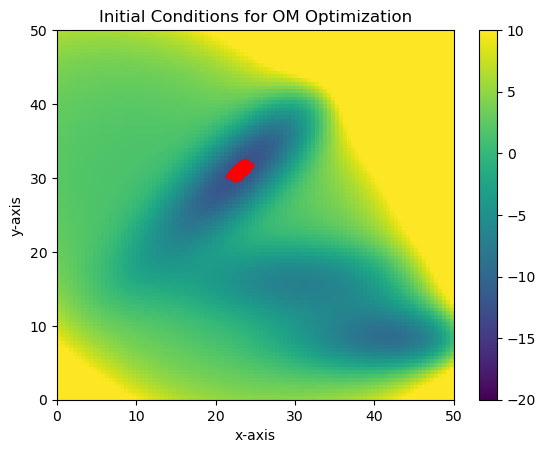

3it [00:00, 20.69it/s]


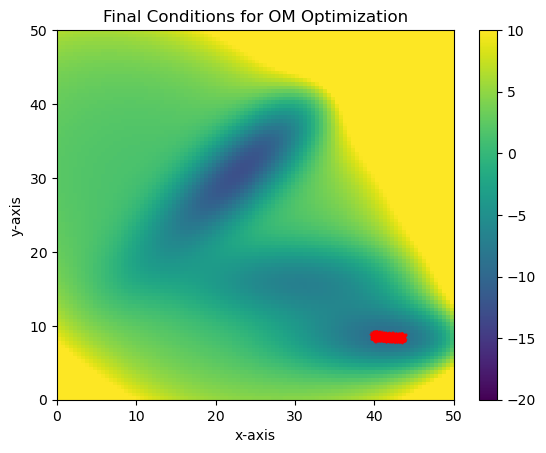

In [10]:
# Run warmup NVT simulations in the basins

from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential
from copy import deepcopy

# run unbiased MD, using the OM-optimized path as initial conditions 
# (use this to make a dataset for diffusion model training)
calculator = MullerBrownPotential(device = "cpu")
x0_dataset = MBDataset(calculator = calculator, initial_positions = x0.unsqueeze(0).cpu(), timestep = 5.0, temperature = 700, n_steps = 100, n_sims = 100, gamma = 0.001)
xf_dataset = MBDataset(calculator = calculator, initial_positions = xf.unsqueeze(0).cpu(), timestep = 5.0, temperature = 700, n_steps = 100, n_sims = 100, gamma = 0.001)

visualize_mb_data(x0_dataset, title="Initial Conditions for OM Optimization")
visualize_mb_data(xf_dataset, title="Final Conditions for OM Optimization")


  0%|          | 0/1000 [00:00<?, ?it/s]

Total action for the step 0 is 12092621.0.


/tmp/ipykernel_4171583/2772330747.py:91: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype="uint8")
 10%|▉         | 98/1000 [00:02<00:17, 52.18it/s]

Total action for the step 100 is 6931959.5.


 20%|█▉        | 195/1000 [00:04<00:13, 59.81it/s]

...

 80%|███████▉  | 799/1000 [00:17<00:03, 58.90it/s]

Total action for the step 800 is 5622993.0.


 90%|████████▉ | 895/1000 [00:19<00:01, 55.66it/s]

Total action for the step 900 is 5620532.5.


100%|██████████| 1000/1000 [00:22<00:00, 45.41it/s]


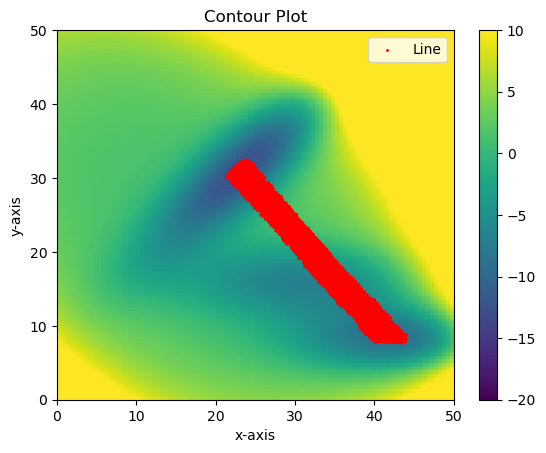

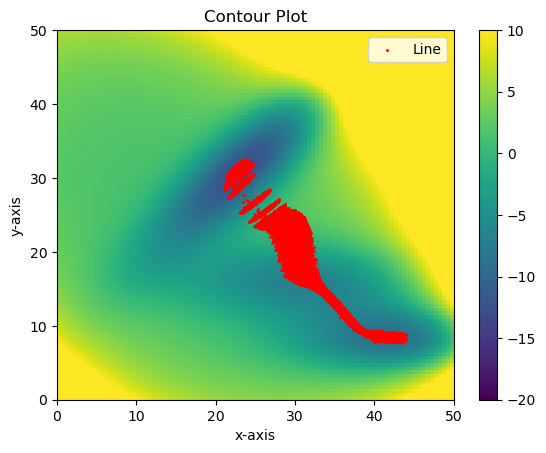

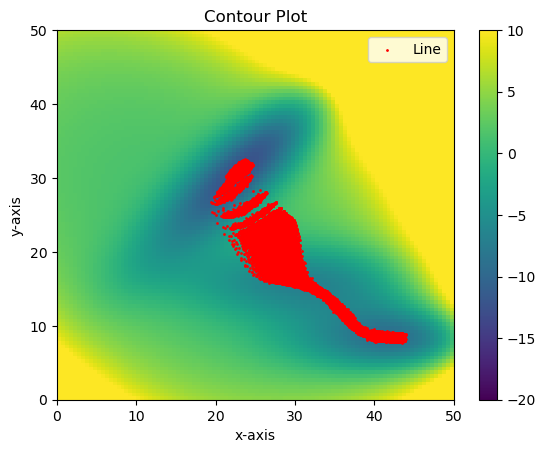

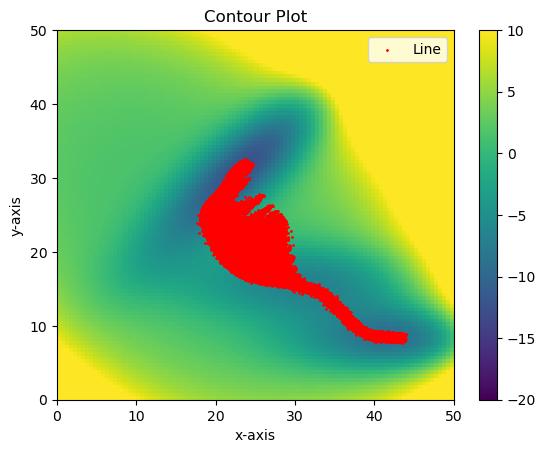

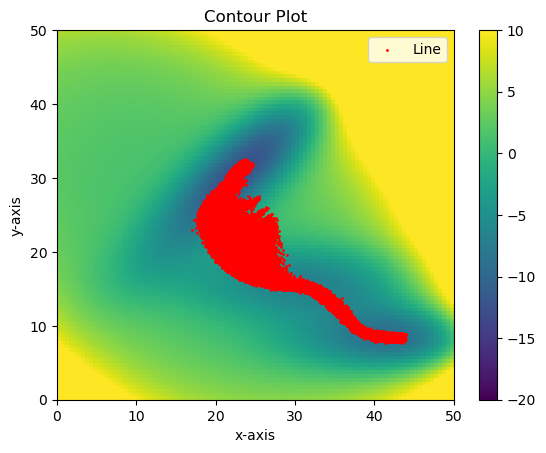

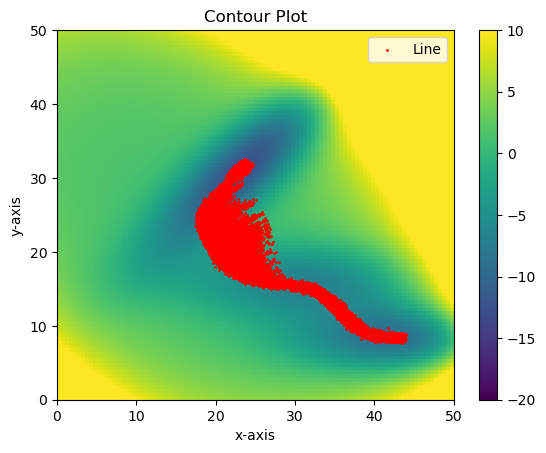

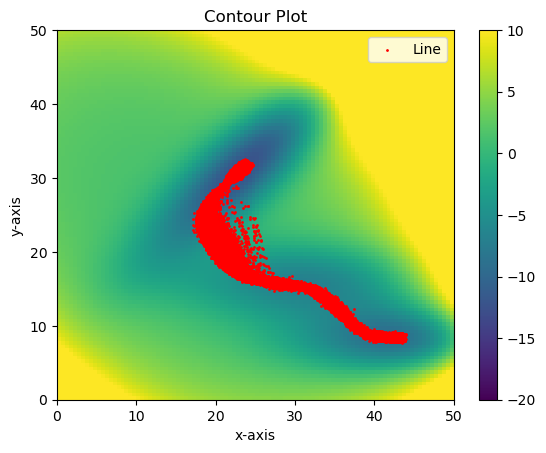

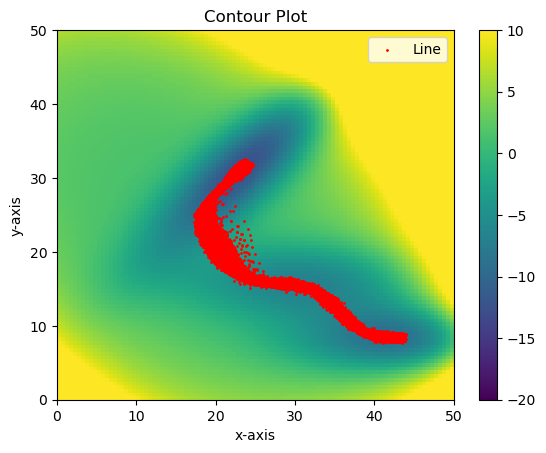

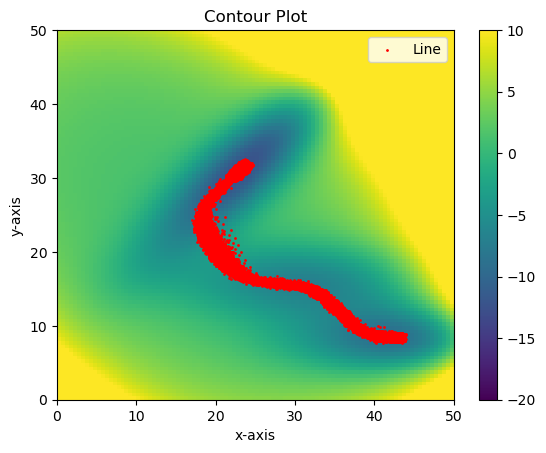

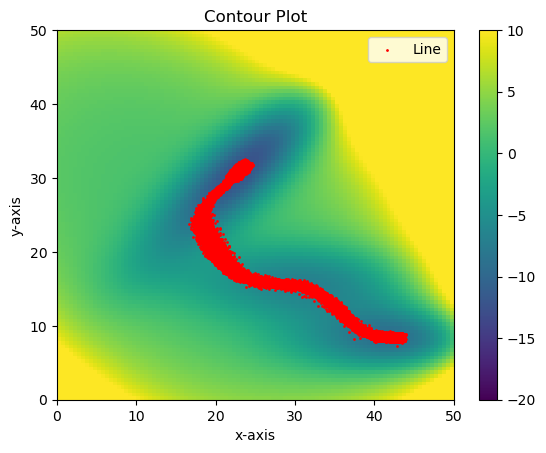

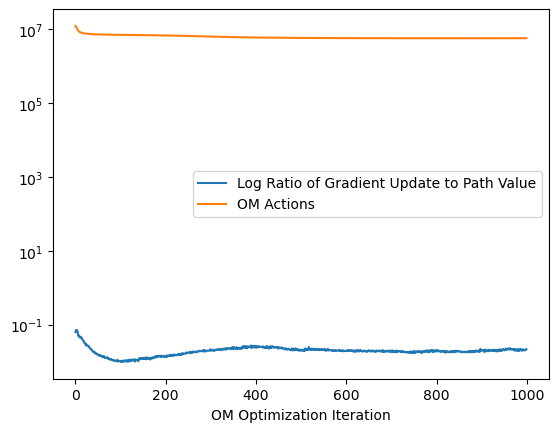

In [11]:
"""Optimization Hyperparameters"""
from functorch import vmap
line_density = 50 # path length
dt = 0.1 # time step to use in action
gamma = torch.tensor(0.1) # gamma value to use in action
D = torch.tensor(0.01) # diffusion coefficient to use in action
#Choose action type
# action_cls = SimpleAction
action_cls = HutchinsonAction
action_func = action_cls(force_func = potential.sample_force_func, laplace_func = potential.laplace, dt = dt, gamma = gamma, D = D)

iterations = 1000 # number of optimization steps
alpha = 2e-1 # learning rate
subsample_points_percent = 0.75 # percentage of points to subsample
subsample_dimensions_percent = 0.75 # percentage of dimensions to subsample
write_every = 100 # how often to write to gif

# line_x = torch.linspace(x0[0], xf[0],line_density)
# line_y = torch.linspace(x0[1], xf[1], line_density)
# line_points = torch.stack((line_x, line_y), axis=-1).unsqueeze(0).to(args.device) # shape [1, line_density, 2]
start_pos = x0_dataset.all_pos.squeeze()
end_pos = xf_dataset.all_pos.squeeze()
line_x = torch.stack([torch.linspace(start[0], end[0], line_density) for start, end in zip(start_pos, end_pos)])
line_y = torch.stack([torch.linspace(start[1], end[1], line_density) for start, end in zip(start_pos, end_pos)])
line_points = torch.stack([line_x, line_y], dim=-1).to(args.device) # shape [n_sims, line_density, 2]

optimizer = torch.optim.Adam([line_points], lr = alpha)

gif_data = []

min_action = 1e9
pbar = tqdm(range(iterations))
ratios = []
actions = []
for i in pbar:
    line_points.requires_grad = True
    action = vmap(action_func, randomness="different")(line_points)
    
    total_action = action.sum()

    optimizer.zero_grad()

    grads, = torch.autograd.grad(total_action, line_points)

    with torch.no_grad():
        grads[:, 0], grads[:, -1] = torch.zeros(2).to(args.device), torch.zeros(2).to(args.device)

        # Subsample points
        num_points = line_density - int(subsample_points_percent * line_density)
        bad_idx = torch.randperm(line_density)[:num_points]
        grads[:, bad_idx] = 0
        
        # Subsample dimensions
        rand = torch.rand_like(grads)
        keep_idx = rand < subsample_dimensions_percent
        grads = grads * keep_idx


        line_points.grad = grads
        optimizer.step()

        grads = grads.cpu()

        
    grad_ratio = alpha * torch.norm(grads, dim = 1) / torch.norm(line_points.cpu(), dim = 1)
    # pbar.set_description(f"Grad update ratio: {grad_ratio.mean().item()}")
    ratios.append(grad_ratio.mean().item())
    actions.append(total_action.item())
    if i % write_every == 0:
        
        print(f"Total action for the step {i} is {(total_action).cpu().detach().numpy()}.")
        draw_points = line_points.detach().cpu()
        # print(f"Total action for the step {i} is {(action).cpu().detach().numpy()}")
        num_points = 100
        x_values = torch.linspace(potential.Lx, potential.Hx , num_points)
        y_values = torch.linspace(potential.Ly, potential.Hy, num_points)

        x, y = torch.meshgrid(x_values.to(args.device), y_values.to(args.device), indexing = 'xy')
        z = potential.U_split(x, y).cpu()

        fig, ax = plt.subplots()
        colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=potential.U_min, vmax=potential.U_max, origin='lower', cmap='viridis', aspect='auto')
        ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
        plt.colorbar(colorbar)

        scatter_plot = ax.scatter(draw_points[:,:, 0], draw_points[:,:, 1], s=1, c='red', label='Line')
        # quiver_plot = ax.quiver(draw_points[:,0], draw_points[:,1], -grads[:,0], -grads[:,1], scale_units='xy', angles='xy', color='blue', alpha=0.7)
        ax.legend()

        fig.canvas.draw()
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype="uint8")
        image = image.reshape(
            fig.canvas.get_width_height()[::-1] + (3,)
        )
        gif_data.append(image)

action_str = "S2" if action_func == S2Action else "simple"
imageio.mimsave(f'MB_{action_str}_linedensity={line_density}_gamma={round(gamma.item(), 1)}_dt={round(dt, 1)}_D={round(D.item(), 1)}.gif', gif_data, fps=3)

plt.figure()
plt.plot(ratios, label = "Log Ratio of Gradient Update to Path Value")
plt.plot(actions, label = "OM Actions")
plt.yscale('log')
plt.xlabel("OM Optimization Iteration")
plt.legend()


Running simulations to collect dataest...


100%|██████████| 100/100 [00:11<00:00,  8.67it/s]
3it [00:00, 19.92it/s]


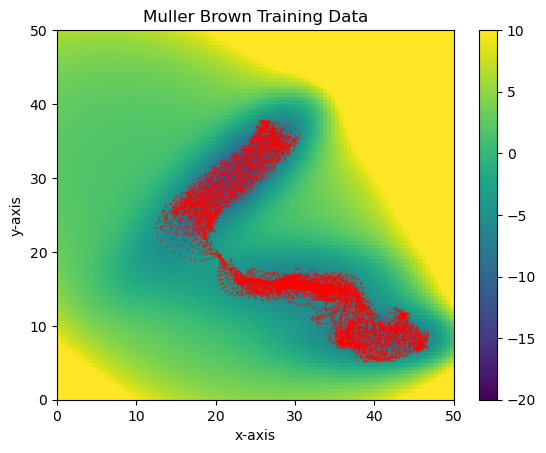

In [41]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential
from copy import deepcopy

# run unbiased MD, using the OM-optimized path as initial conditions 
# (also use this to make a dataset for diffusion model training)
calculator = MullerBrownPotential(device = "cpu")
dataset = MBDataset(save_path = None, calculator = calculator, initial_positions= deepcopy(draw_points[:, 10:30].reshape(-1, 2)).numpy(), timestep = 5.0, temperature = 700, n_steps = 100, n_sims = 100, gamma = 0.001)
# dataset = MBDataset(save_path = 'data', transition_path_guess=None, timestep = 5.0, temperature = 500, n_steps = 100, n_sims = 50)

# dataset = MBDataset(preload_sim_dir="data/temp=1000_timestep=5.0_friction=0.1")
visualize_mb_data(dataset)